In [10]:
from dotenv import load_dotenv
import os

# load .env from the notebook working directory
load_dotenv()
# check if the environment variable is loaded

True

In [11]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("google_genai:gemini-2.5-flash")
response = llm.invoke("What is the capital of France?")

In [12]:
print("Response:", response)

Response: content='The capital of France is **Paris**.' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019caef1-bcc6-7ee1-97ad-f38b9918cfcb-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 8, 'output_tokens': 29, 'total_tokens': 37, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 21}}


In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langgraph.graph.message import add_messages


class ChatbotState(TypedDict):
    # adding a reducer message to the state, which will accumulate the conversation history
    message: Annotated[list, add_messages]

In [14]:
def chatbot_response(state: ChatbotState) -> ChatbotState:
    # Get the last user message
    return {"message": llm.invoke(state["message"])}

graph_builder = StateGraph(ChatbotState)

graph_builder.add_node("chatbot_response", chatbot_response)
graph_builder.add_edge(START, "chatbot_response")
graph_builder.add_edge("chatbot_response", END)

graph = graph_builder.compile()

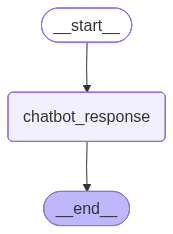

In [15]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))


In [17]:
prompt = [{"role": "user", "content": "What is the capital of France?"}]
response = graph.invoke({"message": prompt})
print("Chatbot response:", response)

Chatbot response: {'message': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='ace4047c-be08-42a9-9bed-f81bc57941ca'), AIMessage(content='The capital of France is **Paris**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019caf0f-4d56-7dc3-8739-66f2b9408dc4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 33, 'total_tokens': 41, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 25}})]}


In [25]:
## Create a new conversation with multiple messages in the history
state = None
while True:
    user_input = input("User: ")
    if user_input.lower() == "exit":
        break

    if state is None:
        state = {"message": [{"role": "user", "content": user_input}]}

    state["message"].append({"role": "user", "content": user_input})
    state = graph.invoke(state)
    # The graph may return langchain message objects (e.g. AIMessage) which are not subscriptable.
    last = state["message"][-1]
    if hasattr(last, 'content'):
        content = last.content
    elif isinstance(last, dict):
        content = last.get("content")
    else:
        content = str(last)
    print("Chatbot:", content)



Chatbot: Hello there! How can I help you today?
Chatbot: The first human moon landing happened on **July 20, 1969**.

It was part of NASA's Apollo 11 mission, and astronaut Neil Armstrong was the first person to step onto the lunar surface.
Chatbot: The first people to land on the Moon were **Neil Armstrong** and **Buzz Aldrin**.

**Neil Armstrong** was the very first person to step onto the lunar surface, followed shortly after by **Buzz Aldrin**. Michael Collins was the third astronaut on the Apollo 11 mission, piloting the command module in orbit around the Moon while Armstrong and Aldrin were on the surface.
Chatbot: Neil Armstrong was from the **United States**.

He was born in Wapakoneta, Ohio.
